# Diabetes Prediction

## EDA

## Step 0: Imports & reading data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

import kagglehub

# Download latest version
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

# Load the latest version
df = pd.read_csv(r"C:\Users\yarah\.cache\kagglehub\datasets\iammustafatz\diabetes-prediction-dataset\versions\1\diabetes_prediction_dataset.csv")

C:\Users\yarah\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Data Understanding
- Dataframe shape
- head and tail
- dtypes
- describe

In [2]:
df.shape

(100000, 9)

In [3]:
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


df.dtypes

In [4]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


## Step 2: Data Preparation
- Drop irrelevant columns and rows
- Identify duplicates
- Rename columns
- Future creation

In [5]:
# We notice that smoking history is not numeric. Let's check the percentage
# of values that are null.
df['smoking_history'].value_counts(dropna=False, normalize=True) * 100

smoking_history
No Info        35.816
never          35.095
former          9.352
current         9.286
not current     6.447
ever            4.004
Name: proportion, dtype: float64

In [6]:
df.groupby('smoking_history', dropna=False)['diabetes'].mean() * 100

smoking_history
No Info         4.059638
current        10.208917
ever           11.788212
former         17.001711
never           9.534122
not current    10.702652
Name: diabetes, dtype: float64

- Ever includes both former and current smokers.
- Not current includes both never and former smokers.
- Therefore, going to use one-hot encoding.

In [7]:
df = pd.get_dummies(df, columns=['smoking_history'], drop_first=False).copy()
# If we're using trees, this is fine.
# If we're using linear regression, we need to drop the healthiest line.

In [8]:
df['gender'].value_counts(dropna=False, normalize=True) * 100

gender
Female    58.552
Male      41.430
Other      0.018
Name: proportion, dtype: float64

In [9]:
# Map the gender values directly, drop unnecessary.
df['gender_encoded'] = df['gender'].map({'Female': 0, 'Male': 1})
df['gender_encoded'].value_counts(dropna=False, normalize=True) * 100

gender_encoded
0.0    58.552
1.0    41.430
NaN     0.018
Name: proportion, dtype: float64

In [10]:
df = df.dropna(subset=['gender_encoded']).reset_index(drop=True)

In [11]:
df.shape

(99982, 15)

In [12]:
df['gender_encoded']= df['gender_encoded'].astype(int)
df['smoking_history_No Info'] = df['smoking_history_No Info'].astype(int)
df['smoking_history_current'] = df['smoking_history_current'].astype(int)
df['smoking_history_ever'] = df['smoking_history_ever'].astype(int)
df['smoking_history_former'] = df['smoking_history_former'].astype(int)
df['smoking_history_never'] = df['smoking_history_never'].astype(int)
df['smoking_history_not current'] = df['smoking_history_not current'].astype(int)


In [13]:
df.head()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,gender_encoded
0,Female,80.0,0,1,25.19,6.6,140,0,0,0,0,0,1,0,0
1,Female,54.0,0,0,27.32,6.6,80,0,1,0,0,0,0,0,0
2,Male,28.0,0,0,27.32,5.7,158,0,0,0,0,0,1,0,1
3,Female,36.0,0,0,23.45,5.0,155,0,0,1,0,0,0,0,0
4,Male,76.0,1,1,20.14,4.8,155,0,0,1,0,0,0,0,1


In [14]:
df = df[['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes', 'smoking_history_No Info',
       'smoking_history_current', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current', 'gender_encoded']]

df.rename(columns={'smoking_history_No Info': 'smoking_history_no_info',
                  'gender_encoded':'gender',
                  'smoking_history_not current':'smoking_history_not_current'})

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_no_info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not_current,gender
0,80.0,0,1,25.19,6.6,140,0,0,0,0,0,1,0,0
1,54.0,0,0,27.32,6.6,80,0,1,0,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,0,0,0,0,1,0,1
3,36.0,0,0,23.45,5.0,155,0,0,1,0,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99977,80.0,0,0,27.32,6.2,90,0,1,0,0,0,0,0,0
99978,2.0,0,0,17.37,6.5,100,0,1,0,0,0,0,0,0
99979,66.0,0,0,27.83,5.7,155,0,0,0,0,1,0,0,1
99980,24.0,0,0,35.42,4.0,100,0,0,0,0,0,1,0,0


## Step 3: Feature Understanding

(Univariate analysis)
- Plotting Feature Distributions
    - Histogram
    - KDE
    - Boxplot

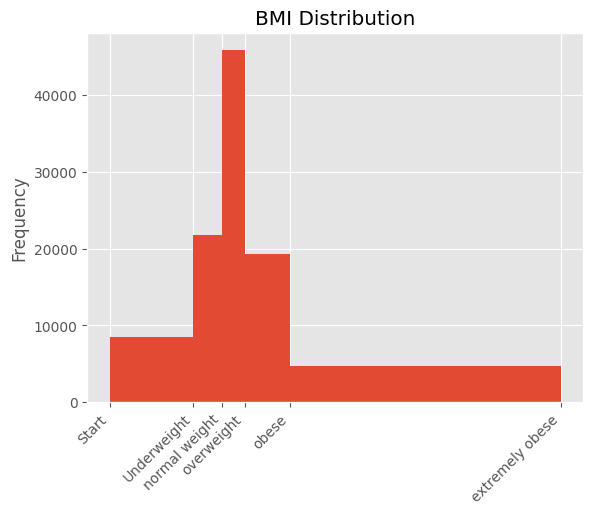

In [15]:
bmi_categories = [0, 18.5, 24.9, 29.9, 39.9, 100]
bmi_labels = ['Start','Underweight', 'normal weight', 'overweight', 'obese', 'extremely obese']

df['bmi'].plot(kind='hist', bins=bmi_categories)
plt.xticks(ticks=bmi_categories, labels=bmi_labels, rotation=45, ha='right')
plt.title("BMI Distribution")
plt.show()

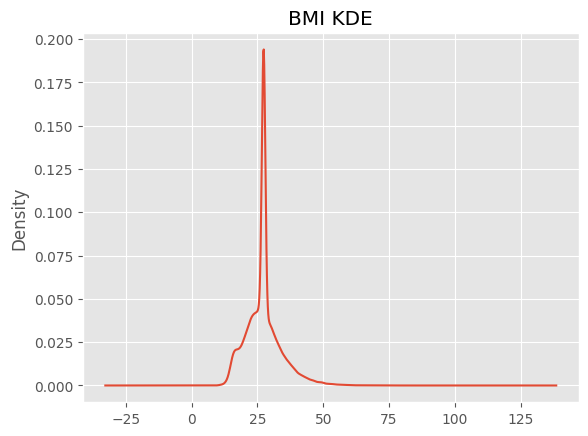

In [16]:
df['bmi'].plot(kind='kde')
plt.title("BMI KDE")
plt.show()

## Step 4: Feature Relationships

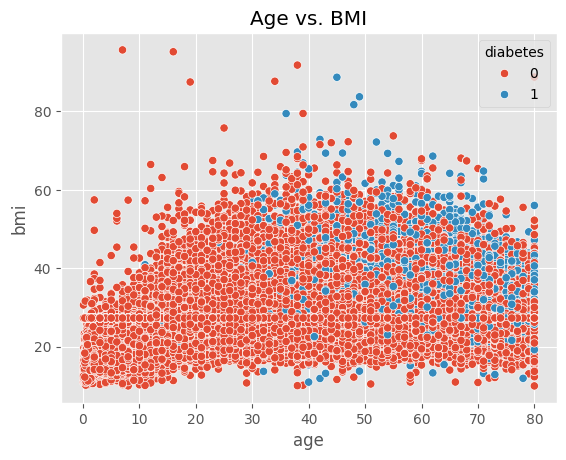

In [17]:
sns.scatterplot(x='age', y='bmi', hue='diabetes', data=df)
plt.title('Age vs. BMI')
plt.show()

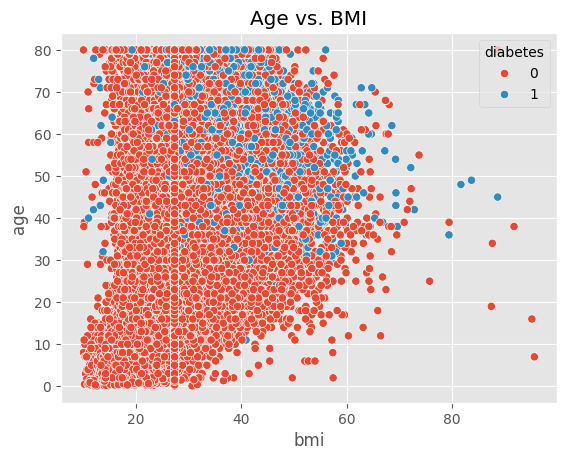

In [18]:
sns.scatterplot(x='bmi', y='age', hue='diabetes', data=df)
plt.title('Age vs. BMI')
plt.show()

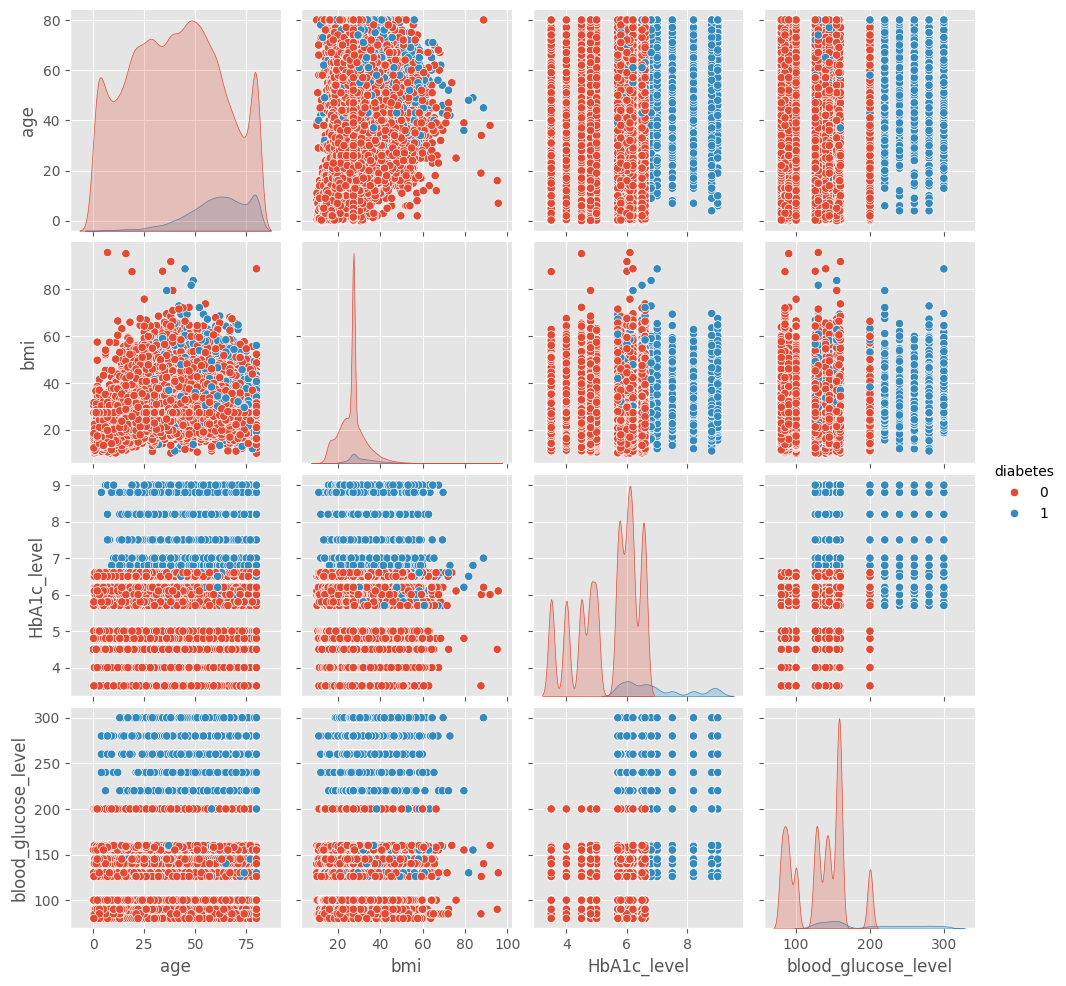

In [19]:
sns.pairplot(df, vars=['age','bmi','HbA1c_level', 'blood_glucose_level'],
            hue='diabetes')
plt.show()

In [20]:
df.columns

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes', 'smoking_history_No Info',
       'smoking_history_current', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current', 'gender_encoded'],
      dtype='object')

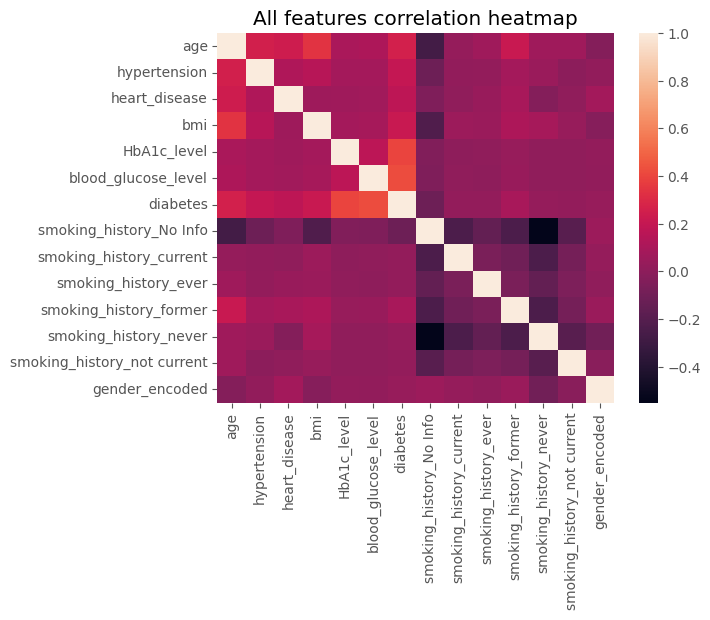

In [21]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix)
plt.title('All features correlation heatmap')
plt.show()

In [22]:
corr_matrix

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,gender_encoded
age,1.000000,0.251163,0.233352,0.337378,0.101343,0.110679,0.257999,-0.276993,0.030917,0.065792,0.216468,0.065423,0.067946,-0.030369
hypertension,0.251163,1.000000,0.121253,0.147679,0.080941,0.084436,0.197811,-0.117223,0.017914,0.023131,0.083386,0.045937,0.001077,0.014381
heart_disease,0.233352,0.121253,1.000000,0.061203,0.067591,0.070071,0.171718,-0.052405,0.007592,0.040679,0.095184,-0.030859,0.007983,0.077886
bmi,0.337378,0.147679,0.061203,1.000000,0.083017,0.091310,0.214377,-0.222579,0.053623,0.044353,0.111322,0.086803,0.035093,-0.023023
HbA1c_level,0.101343,0.080941,0.067591,0.083017,1.000000,0.166831,0.400696,-0.045949,0.006117,0.009702,0.037303,0.010719,0.009676,0.020044
blood_glucose_level,0.110679,0.084436,0.070071,0.091310,0.166831,1.000000,0.419587,-0.051692,0.012450,0.006284,0.040692,0.012463,0.008725,0.017196
diabetes,0.257999,0.197811,0.171718,0.214377,0.400696,0.419587,1.000000,-0.118953,0.019588,0.024088,0.097901,0.027248,0.020831,0.037623
smoking_history_No Info,-0.276993,-0.117223,-0.052405,-0.222579,-0.045949,-0.051692,-0.118953,1.000000,-0.239028,-0.152558,-0.239964,-0.549344,-0.195990,0.053833
smoking_history_current,0.030917,0.017914,0.007592,0.053623,0.006117,0.012450,0.019588,-0.239028,1.000000,-0.065347,-0.102787,-0.235307,-0.083951,0.026589
smoking_history_ever,0.065792,0.023131,0.040679,0.044353,0.009702,0.006284,0.024088,-0.152558,-0.065347,1.000000,-0.065603,-0.150183,-0.053581,0.011005


# Model Creation

## Step 0: Imports

In [23]:
import sklearn

## Step 1: Splitting the train/test data

In [24]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.20, random_state=42)

#s is for scaled, these will be used for algorithms like logistic regression, SVM, KNN, and NN
scaler = sklearn.preprocessing.StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


# We see that 91% of the data is of non-diabetics - the dataset is heavily imbalanced
print(df['diabetes'].value_counts(normalize=True) * 100)

diabetes
0    91.49847
1     8.50153
Name: proportion, dtype: float64


## Step 2: Training the classification models
- Generally: Decision trees, SVM
- For imbalanced data: balanced random forest, XGBoost (possibly catboost)

What are we going to do about the data imbalance? 

First, we are going to train the models (some have the ability to add an extra parameter, some are good with such imbalance).

If the problems persist, we will resample the data.

In [34]:
# 1. Decision Trees
from sklearn.metrics import classification_report

# Initialize decision tree
# Keep class_weight='balanced' due to imbalanced dataset
dt_model = sklearn.tree.DecisionTreeClassifier(
    max_depth=8, 
    class_weight='balanced', 
    random_state=42
)

# 2. Train the model on training data
# Decision Trees do NOT require scaled data, so you can use X_train directly
dt_model.fit(X_train, y_train)

# 3. Make predictions on your test data
dt_preds = dt_model.predict(X_test)

# 4. Evaluate the results
print("--- Decision Tree Performance ---")
print(classification_report(y_test, dt_preds))

# Low precision, lots of false positives

--- Decision Tree Performance ---
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     18222
           1       0.47      0.91      0.62      1775

    accuracy                           0.90     19997
   macro avg       0.73      0.90      0.78     19997
weighted avg       0.94      0.90      0.91     19997



In [26]:
# 2. SVM

# Initialize the SVM Model
# - kernel='rbf': The default "Radial Basis Function". It allows the model to draw complex, curved boundaries instead of just straight lines.
svm_model = sklearn.svm.SVC(kernel='rbf', class_weight='balanced', random_state=42)

# Train the model using the SCALED data
svm_model.fit(X_train_s, y_train)

# Make predictions using the SCALED test data
svm_preds = svm_model.predict(X_test_s)

# Evaluate the results
print("--- SVM Performance ---")
print(classification_report(y_test, svm_preds))

--- SVM Performance ---
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18222
           1       0.45      0.90      0.60      1775

    accuracy                           0.89     19997
   macro avg       0.72      0.90      0.77     19997
weighted avg       0.94      0.89      0.91     19997



In [27]:
# 3. Balanced Random Forest, done using an outer library called imbalanced-learn

# Import from the imblearn library
from imblearn.ensemble import BalancedRandomForestClassifier

# Initialize the specialized model
brf_model = BalancedRandomForestClassifier(
    n_estimators=100,
    random_state=42,
    sampling_strategy='all', # Ensures a strict 50/50 balance for every tree
    n_jobs=-1
)

# Train on raw data
brf_model.fit(X_train, y_train)

# Predict and Evaluate
brf_preds = brf_model.predict(X_test)

print("--- True Balanced Random Forest ---")
print(classification_report(y_test, brf_preds))

--- True Balanced Random Forest ---
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     18222
           1       0.55      0.88      0.68      1775

    accuracy                           0.92     19997
   macro avg       0.77      0.90      0.82     19997
weighted avg       0.95      0.92      0.93     19997



In [28]:
# 4. XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Calculate the exact ratio for scale_pos_weight using TRAINING data ONLY (Why? )
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
imbalance_ratio = neg_class_count / pos_class_count

print(f"Calculated scale_pos_weight: {imbalance_ratio:.2f}")

# Initialize the XGBoost Classifier, pass the imbalance_ratio to force it to care about the minority class
xgb_model = XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    use_label_encoder=False, # Prevents a common warning message
    eval_metric='logloss'    # Standard metric for binary classification
)

# Train the model on the RAW data
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_preds = xgb_model.predict(X_test)

# Evaluate the results
print("\n--- XGBoost Performance ---")
print(classification_report(y_test, xgb_preds))

Calculated scale_pos_weight: 10.89


C:\Users\yarah\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [10:22:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Performance ---
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     18222
           1       0.54      0.89      0.67      1775

    accuracy                           0.92     19997
   macro avg       0.77      0.91      0.82     19997
weighted avg       0.95      0.92      0.93     19997



## Step 5: Random undersampling

We will be resampling as an attempt to increase precision

In [43]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Let's look at the imbalance before we start
print("Before undersampling:", Counter(y_train))

# 1. Initialize the RandomUnderSampler
# setting a random_state ensures you drop the exact same rows every time you run the script
rus = RandomUnderSampler(random_state=42)

# 2. Resample the TRAINING data
# This creates brand new variables containing your perfectly balanced data
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# Let's look at the balance now
print("After undersampling:", Counter(y_train_under))

#s is for scaled, these will be used for algorithms like logistic regression, SVM, KNN, and NN
scaler = sklearn.preprocessing.StandardScaler()
X_train_su = scaler.fit_transform(X_train_under)

Before undersampling: Counter({0: 73260, 1: 6725})
After undersampling: Counter({0: 6725, 1: 6725})


In [44]:
# Decision Trees - After undersampling 

# 1. Decision Trees
from sklearn.metrics import classification_report

# Initialize decision tree
# Keep class_weight='balanced' due to imbalanced dataset
dt_model = sklearn.tree.DecisionTreeClassifier(
    max_depth=8, 
    class_weight='balanced', 
    random_state=42
)

# 2. Train the model on training data
# Decision Trees do NOT require scaled data, so you can use X_train directly
dt_model.fit(X_train_under, y_train_under)

# 3. Make predictions on your test data
dt_preds = dt_model.predict(X_test)

# 4. Evaluate the results
print("--- Decision Tree Performance ---")
print(classification_report(y_test, dt_preds))

# Low precision, lots of false positives

--- Decision Tree Performance ---
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     18222
           1       0.40      0.95      0.56      1775

    accuracy                           0.87     19997
   macro avg       0.70      0.90      0.74     19997
weighted avg       0.94      0.87      0.89     19997



In [46]:
# 2. SVM - After undersampling

# Initialize the SVM Model
# - kernel='rbf': The default "Radial Basis Function". It allows the model to draw complex, curved boundaries instead of just straight lines.
svm_model = sklearn.svm.SVC(kernel='rbf', class_weight='balanced', random_state=42)

# Train the model using the SCALED data
svm_model.fit(X_train_su, y_train_under)

# Make predictions using the SCALED test data
svm_preds = svm_model.predict(X_test_s)

# Evaluate the results
print("--- SVM Performance ---")
print(classification_report(y_test, svm_preds))

--- SVM Performance ---
              precision    recall  f1-score   support

           0       1.00      0.57      0.73     18222
           1       0.18      0.99      0.31      1775

    accuracy                           0.61     19997
   macro avg       0.59      0.78      0.52     19997
weighted avg       0.93      0.61      0.69     19997



In [47]:
# 3. Balanced Random Forest, done using an outer library called imbalanced-learn

# Import from the imblearn library
from imblearn.ensemble import BalancedRandomForestClassifier

# Initialize the specialized model
brf_model = BalancedRandomForestClassifier(
    n_estimators=100,
    random_state=42,
    sampling_strategy='all', # Ensures a strict 50/50 balance for every tree
    n_jobs=-1
)

# Train on raw data
brf_model.fit(X_train_under, y_train_under)

# Predict and Evaluate
brf_preds = brf_model.predict(X_test)

print("--- True Balanced Random Forest ---")
print(classification_report(y_test, brf_preds))

--- True Balanced Random Forest ---
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     18222
           1       0.47      0.91      0.62      1775

    accuracy                           0.90     19997
   macro avg       0.73      0.91      0.78     19997
weighted avg       0.94      0.90      0.91     19997

